In [1]:
import pandas, urllib, numpy

In [2]:
import statsmodels, statsmodels.stats, statsmodels.stats.multitest

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [4]:
# pip install git+https://github.com/Maayanlab/maayanlab-bioinformatics.git
import maayanlab_bioinformatics, maayanlab_bioinformatics.enrichment

# define library

In [5]:
enrichr_library = 'WikiPathways_2024_Mouse'

# read data

In [6]:
df = pandas.read_csv('029 orsay Table DEGs - particular to sets.tsv', sep='\t')
original = df['Particular to HOM'].dropna().values
print(original)
gene_list_input = [element.upper() for element in original]
print(len(gene_list_input), gene_list_input[:10])
# it should be 140 as one is lost bc it was a nan gene, ha!

['H19' 'Ccnd2' 'Itgb2' 'Clec10a' 'Peg3' 'Plin4' 'Dio2' 'Cd163' 'Retn'
 'Prrt1' 'Vtn' 'Scrn1' 'Pdk4' 'Kera' 'Pcbd1' 'Adcy1' 'Krt19' 'Plcd3' 'Ogn'
 'Drd1' 'Npr3' 'Lypd2' 'Cd200r1' 'Adipoq' 'Grik1' 'Igfbp6' 'Cd4' 'Cacna1h'
 'Syt4' 'C2' 'Spink1' 'Rab27b' 'Lox' 'Ms4a6b' 'Ms4a6d' 'Msr1' 'Cyp2e1'
 'Cdk15' 'Rgs16' 'Ccdc3' 'Myoc' 'Lhx6' 'Pck1' 'Kcnq5' 'Depdc1a' 'Tacr1'
 'Slc6a13' 'Plin1' 'Dgat2' 'Itgam' 'Vegfd' 'Cd209d' 'Slit2' 'Col12a1'
 'Apol6' 'Lif' 'Cd300a' 'Plvap' 'Igsf6' 'Arhgap5' 'Mid1' 'Krt17' 'Marchf1'
 'Itih2' 'Tmc3' 'Ccdc68' 'Orm1' 'Gpr176' 'Cacng5' 'Tlr8' 'Dlk1' 'Ramp3'
 'Dnah7b' 'Syt15' 'Rgs8' 'Nmnat2' 'Fam25c' 'Adig' 'Chrm3' 'Stxbp6' 'Ticrr'
 'Nr1h4' 'Igf2' 'Fam167b' 'Vwc2' 'Wfdc21' 'Lrrc15' 'Cysltr1' 'Gas1'
 'Cyp2f2' 'Dpep2' 'Krt15' 'Stfa3' 'Synpr' 'Krtap7-1' 'Cfi' '9630013D21Rik'
 'Ifitm6' 'Pde1a' 'Krtap8-1' '0610040J01Rik' 'Krt79' 'Krt5' 'Cfd'
 'Ftl1-ps1' 'Gm49339' 'Sox11' 'Cnfn' 'Fxyd6' 'Serpinb5' 'Pi15' 'Sprr2a2'
 'Cd300ld4' 'Ccnd1' 'Ccnb1ip1' 'Cstdc5' 'Krtdap' 'Zfp808' 'F630

In [7]:
def get_library(lib_name):
    '''
    Returns a dictionary mapping each term from the input library to 
    its associated geneset. 
    '''
    raw_lib_data = []

    with urllib.request.urlopen('https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=' + lib_name) as f:
        for line in f.readlines():
            raw_lib_data.append(line.decode("utf-8").split("\t\t"))

    name = []
    gene_list = []
    lib_data = {}

    for i in range(len(raw_lib_data)):
        name += [raw_lib_data[i][0]]
        raw_genes = raw_lib_data[i][1].replace('\t', ' ')
        gene_list += [raw_genes[:-1]]
    
    lib_data = {a[0]:a[1].split(' ') for a in zip(name, gene_list)}
    return lib_data

lib_data = get_library(enrichr_library)

enrich_results = maayanlab_bioinformatics.enrichment.enrich_crisp(gene_list_input, lib_data, 21000, True)

res_df = pandas.DataFrame(
    [ [
        term, 
        res.pvalue, 
        res.odds_ratio,
        res.n_overlap,

    ] for (term, res) in enrich_results ], 
    columns=['term', 'pvalue', 'odds_ratio', 'n_overlap']
)
res_df

,term,pvalue,odds_ratio,n_overlap
0,Ethanol Metabolism Resulting In Production Of ...,0.070953,15.000000,1
1,Dysregulated miRNA Targeting In Insulin PI3K A...,0.165327,5.764804,1
2,Factors And Pathways Affecting IGF1 Akt Signal...,0.192818,4.833836,1
3,Nuclear Receptors In Lipid Metabolism And Toxi...,0.018083,10.410295,2
4,Primary Focal Segmental Glomerulosclerosis FSG...,0.382716,2.106495,1
...,...,...,...,...
61,Wnt Signaling WP403,0.062572,5.109555,2
62,Focal Adhesion WP85,0.000255,6.080859,7
63,Apoptosis WP1254,0.411052,1.916805,1
64,GPCRs Other WP41,0.276576,1.961447,2


In [8]:
# add gene names
container = []
for pathway in res_df['term']:
    
    overlap_genes = []
    for query in lib_data[pathway]:
        if query in gene_list_input:
            overlap_genes.append(query)
    mouse_overlap_genes = [element.lower().title() for element in overlap_genes]
    overlap_genes_string = ', '.join(mouse_overlap_genes)
    container.append(overlap_genes_string)

res_df.loc[:, 'overlap_genes'] = container
res_df

,term,pvalue,odds_ratio,n_overlap,overlap_genes
0,Ethanol Metabolism Resulting In Production Of ...,0.070953,15.000000,1,Cyp2E1
1,Dysregulated miRNA Targeting In Insulin PI3K A...,0.165327,5.764804,1,Ccnd2
2,Factors And Pathways Affecting IGF1 Akt Signal...,0.192818,4.833836,1,Igfbp6
3,Nuclear Receptors In Lipid Metabolism And Toxi...,0.018083,10.410295,2,"Nr1H4, Cyp2E1"
4,Primary Focal Segmental Glomerulosclerosis FSG...,0.382716,2.106495,1,Vtn
...,...,...,...,...,...
61,Wnt Signaling WP403,0.062572,5.109555,2,"Ccnd2, Ccnd1"
62,Focal Adhesion WP85,0.000255,6.080859,7,"Ccnd2, Ccnd1, Vtn, Arhgap5, Vegfd, Itgb2, Itgam"
63,Apoptosis WP1254,0.411052,1.916805,1,Igf2
64,GPCRs Other WP41,0.276576,1.961447,2,"Cysltr1, Drd1"


In [9]:
# multiple test correction
results = statsmodels.stats.multitest.multipletests(res_df['pvalue'], alpha=0.05, method='fdr_bh')
res_df['adjusted'] = results[1]

In [10]:
print(min(res_df['adjusted']))

0.002261397827413079


(62, 6)
(4, 6)
1	1.4149277095929647	Adipogenesis Genes WP447	0.002261397827413079
2	1.0455084866114832	Focal Adhesion WP85	0.008405390522443358
3	1.0	Mir 193A And MVP In Colon Cancer Metastasis WP3979	0.014959017931093003


/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_33198/3038667194.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b.loc[:, 'importance'] = importance


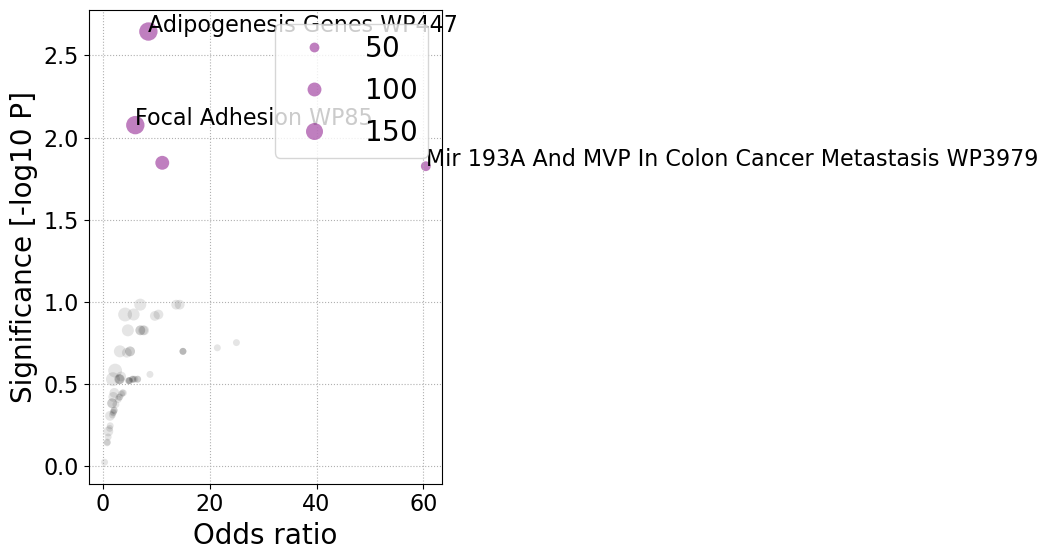

In [12]:
# plot

def importance_calculator(x, y, w):

    xnorm = (x - numpy.min(x)) / (numpy.max(x) - numpy.min(x))
    ynorm = (y - numpy.min(y)) / (numpy.max(y) - numpy.min(y))
    wnorm = (w - numpy.min(w)) / (numpy.max(w) - numpy.min(w))
    
    importance = [numpy.sqrt(xnorm[i]**2 + ynorm[i]**2 + wnorm[i]**2) for i in range(len(x))]
    return importance

inflation = 25

a = res_df[(res_df['adjusted'] > 0.05) | (res_df['odds_ratio'] < 2)]
print(a.shape)
x = a['odds_ratio']
y = -numpy.log10(a['adjusted'])
s = a['n_overlap']
matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/10, edgecolors='none', color='black')

b = res_df[(res_df['adjusted'] < 0.05) & (res_df['odds_ratio'] > 2)]
print(b.shape)
x = b['odds_ratio']
y = -numpy.log10(b['adjusted'])
s = b['n_overlap']
sc = matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/2, edgecolors='none', color='purple')

x = list(b['odds_ratio'])
y = list(-numpy.log10(b['adjusted']))
prez = list(b['term'].values)
z = [element.split()[-1] for element in prez]
importance = importance_calculator(x, y, s.values)
b.loc[:, 'importance'] = importance
c = b.sort_values('importance', ascending=False)

threshold = importance[numpy.argsort(importance)[::-1][3]] # gimme the top 3
com = c[c['importance'] > threshold]
count = 0
for index, row in com.iterrows():
    x = row['odds_ratio']
    y = -numpy.log10(row['adjusted'])
    
    label = ' '.join(row['term'].split()[:2])
    label = row['term']
    matplotlib.pyplot.text(x, y, label, fontsize=16)
    count = count + 1
    print('{}\t{}\t{}\t{}'.format(count, row['importance'], row['term'], row['adjusted']))

matplotlib.pyplot.legend(*sc.legend_elements("sizes", num=3, color='purple', alpha=1/2, mew=0), loc=1)
matplotlib.pyplot.xlabel('Odds ratio')
matplotlib.pyplot.ylabel('Significance [-log10 P]')
matplotlib.pyplot.grid(ls=':', alpha=1)
matplotlib.pyplot.tight_layout()

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('hom.svg')

In [ ]:
# store list 
print(c.shape)
c.drop('pvalue', axis='columns', inplace=True)
d = c.iloc[:, [0, 5, 4, 1, 2, 3]]
d.rename(columns={"term": "Term", 
                  "importance": "Priority", 
                  'adjusted':'Adjusted P', 
                  'odds_ratio':'Odds ratio',
                 'n_overlap':'N overlap',
                 'overlap_genes':'Overlap genes'}, inplace=True)
d.set_index('Term', inplace=True)
d.head()
d.to_csv('particular2both.wikipathways.tsv', sep='\t')

d